## scRNA Mouse Erythroid Quick Run

1. This notebook provides a compact, end-to-end workflow showing how to run STEER on single-cell RNA velocity data from the mouse erythroid lineage. The default setup uses `training_mode="full"` so users can see the standard two-stage STEER pipeline on a real scRNA-seq dataset.

2. If GPU memory is limited, `velo_batch_size` is the main parameter to reduce memory usage during the kinetics-learning stage. The full run can take substantial GPU time, so the `"fast"` profile is useful for quick checks before a longer run.

All main-figure results associated with this project are available on Zenodo: `10.5281/zenodo.18713189`.

## Input

The recommended input is an `AnnData` object containing at least `spliced` and `unspliced` layers. Optional metadata such as cell types or developmental stages can be kept in `adata.obs` for downstream interpretation, but spatial coordinates are not required for this single-cell workflow.


In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import seaborn as sns
import torch
import torch.backends.cudnn as cudnn

import steer
from steer.prior.prior import PriorInferenceManager

warnings.filterwarnings("ignore")
%matplotlib inline

print("=== STEER Quick Start Environment ===")
print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")
print(f"scVelo version: {scv.__version__}")
print(f"STEER version: {getattr(steer, '__version__', 'dev build')}")
print("====================================")

=== STEER Quick Start Environment ===
PyTorch version: 2.8.0+cu128
Scanpy version: 1.10.2
scVelo version: 0.3.3
STEER version: 2.2.2


## Config

1. This section includes only the settings that users are most likely to modify. The current default setup uses `training_mode="full"`, which matches the configuration used to generate the results shown in this notebook.

- `"full"`: uses the default STEER training arguments without overrides and runs the complete training schedule.
- `"fast"`: uses a lightweight, quickstart-style parameter set for faster demos and iteration.

- For advanced usage, you can further customize the `"fast"` setting in `get_stage1_training_overrides` and `get_stage2_training_overrides`. For example, you may remove the `epochs` and `patience` settings to fall back to the same defaults as `"full"` mode, while still adjusting `velo_batch_size` to reduce GPU memory usage. This can provide more thorough training than the default `"fast"` mode while requiring less GPU memory than `"full"` mode.

2. Only the most important settings are exposed here:

- `data_name` / `input_dir` / `result_dir`: control input and output locations

- For a first run on a new dataset, it is usually enough to update the data path and `training_mode`.


In [2]:
class Config:
    # Data
    data_name = "erythroid_lineage"
    input_dir = "/nvme/users/liuzhy/Review_Files/8_MouseGastrulation/erythroid_lineage_data/"
    result_dir = "./results_fast"
    seed = 618

    # Core model and graph settings
    expert = 10  # Number of experts. You can adjust this based on biological prior knowledge
                 # or an estimated cluster number (see quickstart.ipynb).
    smooth_neigh = 100  # Number of neighbors used for smoothing.
                       # Usually 50-100 works well; increase for noisier data.
    # Training profile
    training_mode = "fast"    # Choose from "full" or "fast".
    finetune_epochs = 5000  # Only used when training_mode == "fast".

    # Advanced settings
    corr_mode = "u"  # Use unspliced counts for temporal supervision.
                     # If time inference is unsatisfactory and unspliced counts are low,
                     # try setting this to "s" and rerun.
    neighbor_metric = "cosine"  # Neighbor metric. You can also use Euclidean distance.
    use_us = True  # Use both unspliced and spliced counts as input features.
    use_filter = True  # Filter genes before kinetics learning to keep informative genes.
    filter_gene_number = 1000  # Number of genes kept when filtering is enabled.

    # Prior-inference settings for single-cell data
    fine_method = "none" # "hierarchical"
    target_size = 300
    direction_base = "expert"# "fine"

cfg = Config()

INPUT_FILE = os.path.join(cfg.input_dir, f"{cfg.data_name}.h5ad")
RESULT_PATH = os.path.join(cfg.result_dir, f"{cfg.data_name}_quickstart")
os.makedirs(RESULT_PATH, exist_ok=True)


def get_stage1_training_overrides(mode: str) -> dict:
    if mode == "full":
        return {}
    if mode == "fast":
        return {
            "expert_mode": "slim",
            "pretrain_epochs": 500,
            "cluster_epochs": 200,
        }
    raise ValueError(f"Unsupported training_mode: {mode}")


def get_stage2_training_overrides(mode: str, finetune_epochs=None) -> dict:
    if mode == "full":
        return {}
    if mode == "fast":
        if finetune_epochs is None:
            raise ValueError("cfg.finetune_epochs must be set when training_mode='fast'.")
        return {
            "expert_mode": "slim",
            "pretrain_epochs": 500,
            "cluster_epochs": 200,
            "velo_batch_size": 2048,
            "MIN_IMPRO": 0.001,
            "PATIENCE": 500,
            "num_epochs": finetune_epochs,
        }
    raise ValueError(f"Unsupported training_mode: {mode}")


print(f"Input file: {INPUT_FILE}")
print(f"Output directory: {RESULT_PATH}")
print(f"Training mode: {cfg.training_mode}")


Input file: /nvme/users/liuzhy/Review_Files/8_MouseGastrulation/erythroid_lineage_data/erythroid_lineage.h5ad
Output directory: ./results_fast/erythroid_lineage_quickstart
Training mode: fast


## Seed And Device

This cell fixes the random seed for reproducibility and automatically selects GPU or CPU.


In [3]:
def setup_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

setup_seed(cfg.seed)
# you need to use your device number
if torch.cuda.is_available():
    device = torch.device("cuda:1")
print(f"Using device: {device}")

Using device: cuda:1


## Load Data

Load the `.h5ad` file and check that the required layers are present. When users switch to their own data, this is usually the first place where formatting issues appear.


In [4]:
adata = sc.read_h5ad(INPUT_FILE)
if "X_pca" in adata.obsm:
    del adata.obsm["X_pca"]

if "celltype1" in adata.obs and "celltype" not in adata.obs:
    adata.obs["celltype"] = adata.obs["celltype1"]

print(adata)
print("\nAvailable layers:", list(adata.layers.keys()))
print("Available obsm keys:", list(adata.obsm.keys()))
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")

required_layers = ["spliced", "unspliced"]
missing_layers = [layer for layer in required_layers if layer not in adata.layers]
if missing_layers:
    raise ValueError(f"Missing required layers: {missing_layers}")
if "celltype" not in adata.obs:
    print("Warning: adata.obs['celltype'] not found. Downstream plots will need another annotation key.")


AnnData object with n_obs × n_vars = 9815 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors'
    obsm: 'X_umap'
    layers: 'spliced', 'unspliced'

Available layers: ['spliced', 'unspliced']
Available obsm keys: ['X_umap']
Number of cells: 9815
Number of genes: 53801


In [5]:
adata

AnnData object with n_obs × n_vars = 9815 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors'
    obsm: 'X_umap'
    layers: 'spliced', 'unspliced'

## Preprocess

Run the basic normalization step and build the dataframe, adjacency matrix, and processed `AnnData` object required by STEER.


In [6]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)

df, adjacency_matrix, adata = steer.preprocess_anndata(
    adata,
    npc=30,
    NUM_AD_NEIGH=30,
    SMOOTH_NEIGH=cfg.smooth_neigh,
    moments_adj=True,
    neighbor_metric=cfg.neighbor_metric,
    use_us=cfg.use_us,
)

print(df.head())
print("\nAdjacency matrix shape:", adjacency_matrix.shape)

Filtered out 47456 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/nvme/users/liuzhy/miniconda3/envs/steer_dev/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
           cellID gene_name  unsplice    splice  orig_unsplice  orig_splice  \
0  AAAGATCTCTCGAA   Arfgef1  0.317008  0.599340            0.0     0.000000   
1  AATCTCACTGCTTT   Arfgef1  0.498130  0.691799            0.0     1.778597   
2  AATGGCTGAAGATG   Arfgef1  0.547252  0.733817            0.0     1.034375   
3  ACACATCTGTCAAC   Arfgef1  0.244253  0.499608            0.0     0.000000   
4  ACGACAACTGGAGG   Arfgef1  0.319506  0.592695            0.0     0.000000   

         Mu        Ms  
0  0.066035  0.201642  
1  0.103764  0.232749  
2  0.113997  0.246885  
3  0.050880  0.168088  
4  0.066556  0.199406  

Adjacency matrix shape: (9815, 9815)


## Expert Number

The expert number used in this workflow was originally chosen from an estimation step rather than fixed arbitrarily. For reproduce the results, `cfg.expert` is directly set to `10`, and the optional helper below can be used to re-estimate the expert number directly from the processed embedding before training.


In [7]:
cfg.expert = 5

## Build PyG Input

Package the current dataset into the PyTorch Geometric objects required by STEER training.


In [8]:
dataset = steer.preload_datasets_all_genes_anndata(df=df, MODEL_MODE="pretrain", adata=adata)
pyg_data = steer.create_pyg_data(dataset, adjacency_matrix, normalize=True)

print(pyg_data)

Data(x=[9815, 4000], edge_index=[2, 373875], type_features=[9815, 2000], orig_features=[9815, 4000], cell_ids=[9815], adj=[9815, 9815])


## Stage 1 Training

Train the first-stage model to obtain the initial representation and cluster structure.

- `full` mode: do not override training epochs or related controls, so STEER uses its built-in defaults
- `fast` mode: apply a lightweight quickstart-style configuration for a faster tutorial run


In [9]:
stage1_kwargs = dict(
    device=device,
    device2=device,
    pyg_data=pyg_data,
    MODEL_MODE="pretrain",
    adata=adata,
    NUM_LOSS_NEIGH=30,
    corr_mode=cfg.corr_mode,
    max_n_cluster=cfg.expert,
    path=RESULT_PATH,
)
stage1_kwargs.update(get_stage1_training_overrides(cfg.training_mode))

result_adata = steer.model_training_share_neighbor_adata(**stage1_kwargs)


Epoch 0, Loss 0.12326658517122269
Epoch 50, Loss 0.06401439011096954
Epoch 100, Loss 0.05739820376038551
Epoch 150, Loss 0.051992498338222504
Epoch 200, Loss 0.047516319900751114
Epoch 250, Loss 0.043695274740457535
Epoch 300, Loss 0.04043680429458618
Epoch 350, Loss 0.03751787170767784
Epoch 400, Loss 0.03471369296312332
Epoch 450, Loss 0.032336171716451645
Epoch 500, Loss 1.071047067642212
Epoch 550, Loss 0.09146970510482788
Epoch 600, Loss 0.07198427617549896
Epoch 650, Loss 0.0666075050830841


## Optional `mclust`

If R and `rpy2` are available, this step runs `mclust` once for optional clustering refinement. Otherwise, it is skipped automatically.


In [10]:
try:
    result_adata = steer.mclust_R(result_adata, num_cluster=cfg.expert)
    print("Initial clustering with mclust completed.")
except Exception as e:
    print("mclust step skipped.")
    print(f"Reason: {e}")

torch.cuda.empty_cache()

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.

/nvme/users/liuzhy/miniconda3/envs/steer_dev/lib/python3.10/site-packages/rpy2/robjects/numpy2ri.py:241: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '


fitting ...
  |======================================================================| 100%
Initial clustering with mclust completed.


## Prior Inference

Infer the kinetic prior from the first-stage result for use in the downstream kinetic-learning stage.


--- Task 1: Generating Fine Clusters (Method: none) ---
  -> Method is 'none', copying Expert clusters to Fine clusters.
--- Task 2: Filtering Genes (Based on: EXPERT, Keep: 1000) ---
--- Task 3: Calculating Direction (Based on: EXPERT) ---
Starting parallel processing with n_jobs=-1...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done 194 tasks      | elapsed:   19.2s
[Parallel(n_jobs=-1)]: Done 392 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done 626 tasks      | elapsed:   20.8s
[Parallel(n_jobs=-1)]: Done 896 tasks      | elapsed:   21.4s
[Parallel(n_jobs=-1)]: Done 1202 tasks      | elapsed:   21.9s
[Parallel(n_jobs=-1)]: Done 1544 tasks      | elapsed:   22.4s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   23.1s finished


Aggregating results...
Done.
--- Finalizing: Restoring Expert labels & Preparing Fine Cluster Vector ---
Prior inference completed.


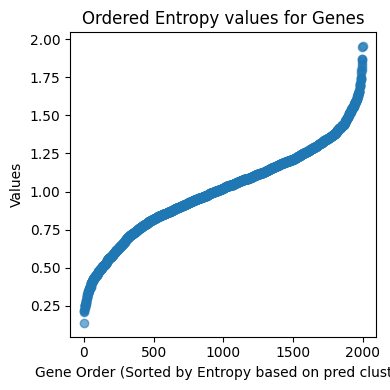

In [11]:
prior_manager = PriorInferenceManager(result_adata, df, RESULT_PATH, seed=cfg.seed)
prior_manager.task1_define_fine_clusters(method=cfg.fine_method, target_size=cfg.target_size)
prior_manager.task2_filter_genes(based_on="expert", keep_ngene=cfg.filter_gene_number, use_filter=cfg.use_filter)
prior_manager.task3_calc_convexity(based_on=cfg.direction_base)

result_adata, df_updated, fine_clus_vec_np = prior_manager.finalize_for_training()
print("Prior inference completed.")

## Velocity Dataset

Subset to velocity genes and rebuild the data objects required for the second training stage.


In [12]:
prior_adata = result_adata.copy()

raw_adata = sc.read_h5ad(INPUT_FILE)
if "X_pca" in raw_adata.obsm:
    del raw_adata.obsm["X_pca"]
if "celltype1" in raw_adata.obs and "celltype" not in raw_adata.obs:
    raw_adata.obs["celltype"] = raw_adata.obs["celltype1"]

scv.pp.filter_and_normalize(
    raw_adata,
    min_shared_counts=20,
    n_top_genes=2000,
)

assert all(prior_adata.obs_names == raw_adata.obs_names), "Observation names are not aligned!"
assert all(prior_adata.var_names == raw_adata.var_names), "Variable names are not aligned!"

raw_adata.layers["pred_cell_type"] = prior_adata.layers["pred_cell_type"]
raw_adata.obsm["X_pre_embed"] = prior_adata.obsm["X_pre_embed"]
raw_adata.obs["pred_cluster"] = prior_adata.obs["pred_cluster"].astype(int)

velo_adata = raw_adata[:, prior_adata.var["is_velocity_gene"]].copy()

df_fine, adjacency_matrix_fine, velo_adata = steer.preprocess_anndata(
    velo_adata,
    npc=30,
    NUM_AD_NEIGH=30,
    SMOOTH_NEIGH=cfg.smooth_neigh,
    moments_adj=True,
    neighbor_metric=cfg.neighbor_metric,
    use_us=cfg.use_us,
)

dataset_fine = steer.preload_datasets_all_genes_anndata(
    df=df_fine,
    MODEL_MODE="whole",
    adata=velo_adata,
)
pyg_data_fine = steer.create_pyg_data(dataset_fine, adjacency_matrix_fine, normalize=True)
pyg_data_fine.fine_clus_vec = torch.tensor(fine_clus_vec_np, dtype=torch.long, device=device)

print(velo_adata)
print("Velocity-gene subset shape:", velo_adata.shape)


Filtered out 47456 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/nvme/users/liuzhy/miniconda3/envs/steer_dev/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
AnnData object with n_obs × n_vars = 9815 × 1000
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'pred_cluster'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'celltype_colors', 'log1p', 'neighbors'
    obsm: 'X_umap', 'X_pre_embed', 'X_pca_combined', 'X_pca_moments'
    layers: 'spliced', 'unspliced', 'pred_cell_type', 'Ms', 'Mu', 'scale_Mu', 'scale_Ms'
    obsp: 'distances', 'connectivities'
Velocity-gene subset shape: (9815, 1000)


## Kinetic Learning

Run the main kinetic-learning stage using the prior inferred above.

- `full` mode: preserve the behavior of your original run by not passing extra training-control arguments and therefore using STEER defaults
- `fast` mode: use a lightweight quickstart-style configuration, including `expert_mode="slim"`, shorter pretraining/clustering, `velo_batch_size=512`, and more aggressive early stopping


In [13]:
stage2_kwargs = dict(
    device=device,
    device2=device,
    pyg_data=pyg_data_fine,
    MODEL_MODE="whole",
    adata=velo_adata,
    NUM_LOSS_NEIGH=30,
    max_n_cluster=cfg.expert,
    corr_mode=cfg.corr_mode,
    path=RESULT_PATH,
)
stage2_kwargs.update(
    get_stage2_training_overrides(
        cfg.training_mode,
        getattr(cfg, "finetune_epochs", None),
    )
)

velo_adata = steer.model_training_share_neighbor_adata(**stage2_kwargs)

print("Kinetic-learning stage completed.")


Using Fine Cluster Vector for Correlation Loss.
Epoch 0, Loss 0.14109943807125092
Epoch 50, Loss 0.08040767163038254
Epoch 100, Loss 0.0727798119187355
Epoch 150, Loss 0.0665828213095665
Epoch 200, Loss 0.06125184893608093
Epoch 250, Loss 0.05659956857562065
Epoch 300, Loss 0.052438072860240936
Epoch 350, Loss 0.04880218207836151
Epoch 400, Loss 0.045311491936445236
Epoch 450, Loss 0.042271632701158524
Epoch 500, Loss 1.08180832862854
Epoch 550, Loss 0.10931762307882309
Epoch 600, Loss 0.08053947985172272
Epoch 650, Loss 0.07452398538589478
Epoch 700, Loss 0.0709378719329834
Epoch 750, Loss 1.0369415283203125
GATE: 0.03271901234984398, Cluster: 0.03608018159866333, Time_cor: 0.9533256888389587, Time_smooth: 0.014816690236330032
Epoch 800, Loss 1.0325865745544434
GATE: 0.030481768772006035, Cluster: 0.03579676151275635, Time_cor: 0.9523569941520691, Time_smooth: 0.013951120898127556
Epoch 850, Loss 1.0295418500900269
GATE: 0.02857108786702156, Cluster: 0.03580904006958008, Time_cor: 0.9

## Velocity Visualization

Build the velocity graph and inspect the learned flow field in latent space and on the expression UMAP.


In [14]:
result_adata = velo_adata.copy()

sc.pp.neighbors(result_adata, n_neighbors=30, use_rep="X_para_t", key_added="para_t_neighbors")
temp_adata = sc.tl.umap(result_adata, neighbors_key="para_t_neighbors", copy=True)
result_adata.obsm["X_umap_para_t_embed"] = temp_adata.obsm["X_umap"]

sc.pp.neighbors(result_adata, n_neighbors=30, use_rep="X_para", key_added="para_neighbors")
temp_adata = sc.tl.umap(result_adata, neighbors_key="para_neighbors", copy=True)
result_adata.obsm["X_umap_para_embed"] = temp_adata.obsm["X_umap"]

sc.pp.neighbors(result_adata, n_neighbors=30, use_rep="X_refine_embed_t", key_added="refine_embed_t_neighbors")
temp_adata = sc.tl.umap(result_adata, neighbors_key="refine_embed_t_neighbors", copy=True)
result_adata.obsm["X_umap_refine_embed_t"] = temp_adata.obsm["X_umap"]

sc.pp.neighbors(result_adata, use_rep="X_refine_embed", n_neighbors=30)
steer.velocity_graph(result_adata, vkey="pred_vs_norm", xkey="model_Ms")

print("obs columns:")
print(sorted(result_adata.obs.columns.tolist()))

print("\nobsm keys:")
print(sorted(result_adata.obsm.keys()))

print("\nlayers:")
print(sorted(result_adata.layers.keys()))


computing velocity graph (using 1/128 cores)


  0%|          | 0/9815 [00:00<?, ?cells/s]

    finished (0:00:10) --> added 
    'pred_vs_norm_graph', sparse matrix with cosine correlations (adata.uns)
obs columns:
['Expert', 'Expert Weight', 'Pred Time', 'celltype', 'initial_size', 'initial_size_spliced', 'initial_size_unspliced', 'n_counts', 'pred_vs_norm_self_transition', 'pretrain_cluster', 'sample', 'sequencing.batch', 'stage', 'theiler']

obsm keys:
['X_alpha', 'X_beta', 'X_gamma', 'X_para', 'X_para_t', 'X_pca_combined', 'X_pca_moments', 'X_pre_embed', 'X_refine_embed', 'X_refine_embed_t', 'X_umap', 'X_umap_para_embed', 'X_umap_para_t_embed', 'X_umap_refine_embed_t', 'cluster_matrix']

layers:
['final_recon_s', 'final_recon_u', 'init_regulate_state', 'model_Ms', 'model_Mu', 'orig_s', 'orig_u', 'pred_time_layer', 'pred_vs', 'pred_vs_norm', 'pred_vu', 'pred_vu_norm', 'recon_alpha', 'recon_alpha_norm', 'recon_beta', 'recon_gamma', 'recon_gamma_norm', 'regulate_state', 'scale_Ms', 'scale_Mu']


In [15]:
result_adata

AnnData object with n_obs × n_vars = 9815 × 1000
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'pretrain_cluster', 'Expert', 'Expert Weight', 'Pred Time', 'pred_vs_norm_self_transition'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'celltype_colors', 'log1p', 'neighbors', 'para_t_neighbors', 'para_neighbors', 'refine_embed_t_neighbors', 'pred_vs_norm_graph', 'pred_vs_norm_graph_neg', 'pred_vs_norm_params'
    obsm: 'X_umap', 'X_pre_embed', 'X_pca_combined', 'X_pca_moments', 'X_refine_embed', 'cluster_matrix', 'X_alpha', 'X_beta', 'X_gamma', 'X_para', 'X_para_t', 'X_refine_embed_t', 'X_umap_para_t_embed', 'X_umap_para_embed', 'X_umap_refine_embed_t'
    layers: 'scale_Mu', 'scale_Ms', 'recon_alpha', 'recon_beta', 'recon_gamma', 'pred_vu', 'pred_vs', 

computing velocity embedding
    finished (0:00:01) --> added
    'pred_vs_norm_umap_refine_embed_t', embedded velocity vectors (adata.obsm)
saving figure to file ./results_fast/erythroid_lineage_quickstart/scvelo_velo_latent_umap.png


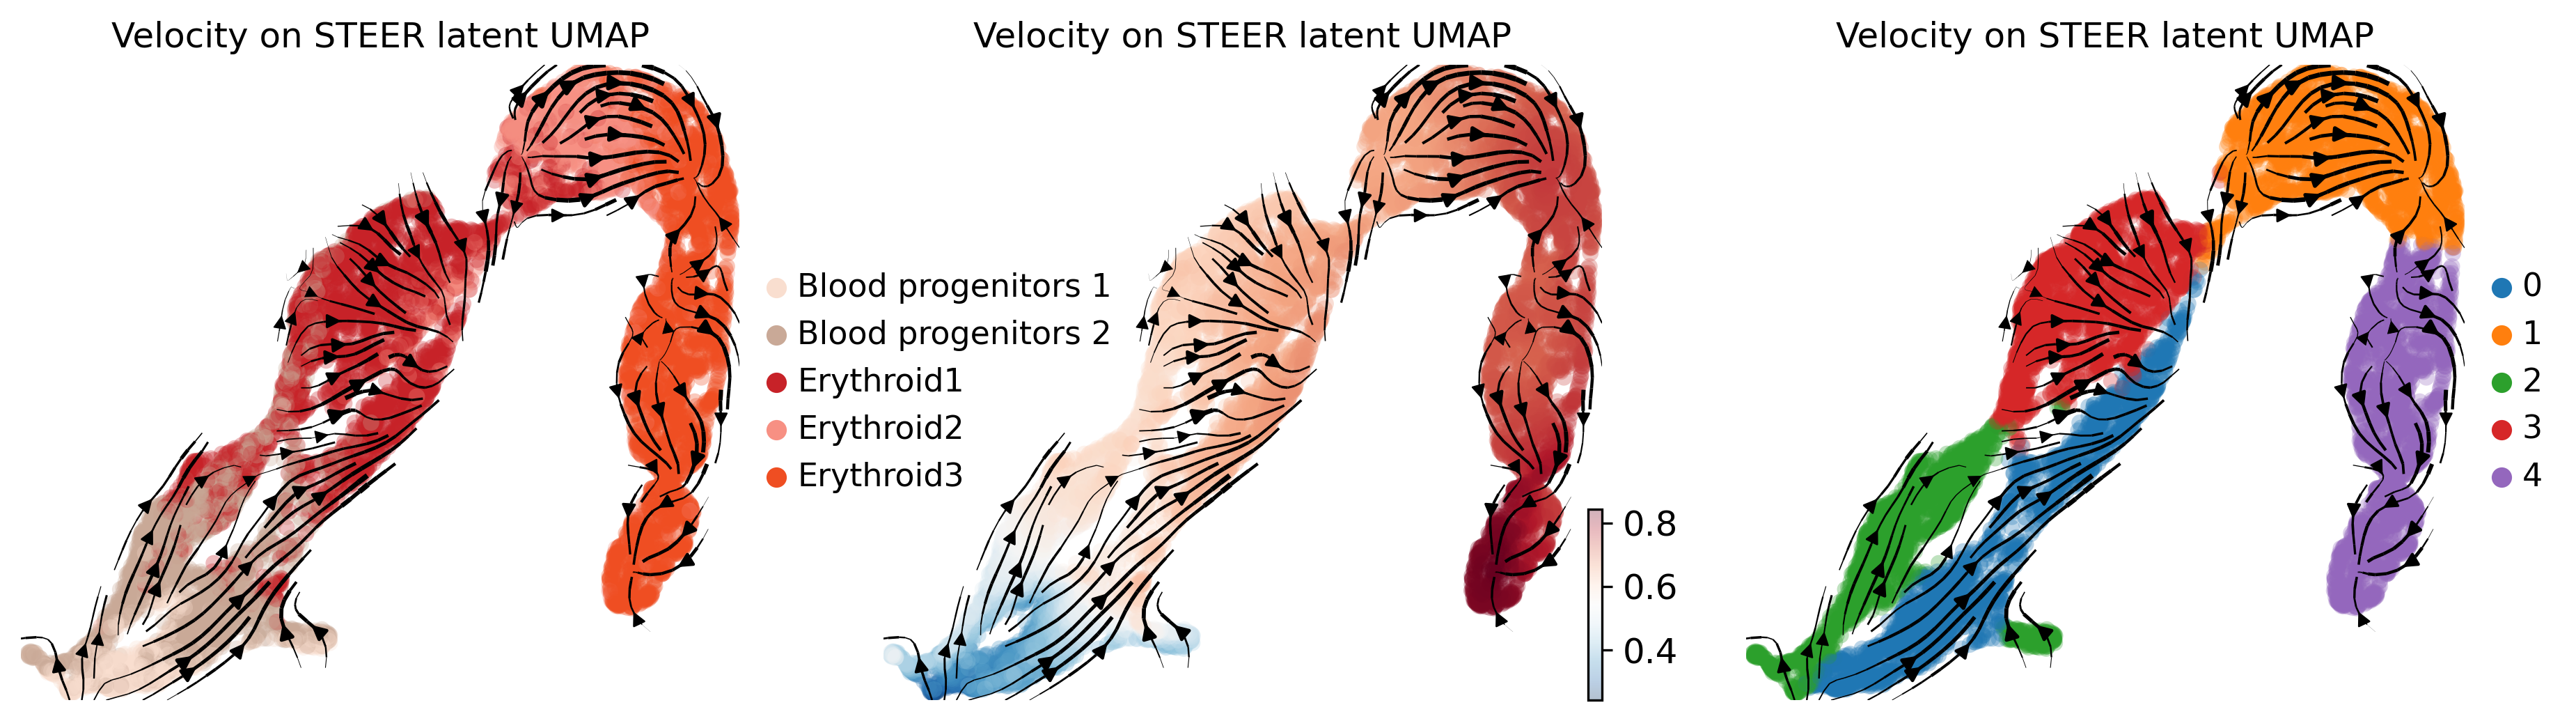

computing velocity embedding
    finished (0:00:01) --> added
    'pred_vs_norm_umap', embedded velocity vectors (adata.obsm)
saving figure to file ./results_fast/erythroid_lineage_quickstart/scvelo_velo_expression_umap.png


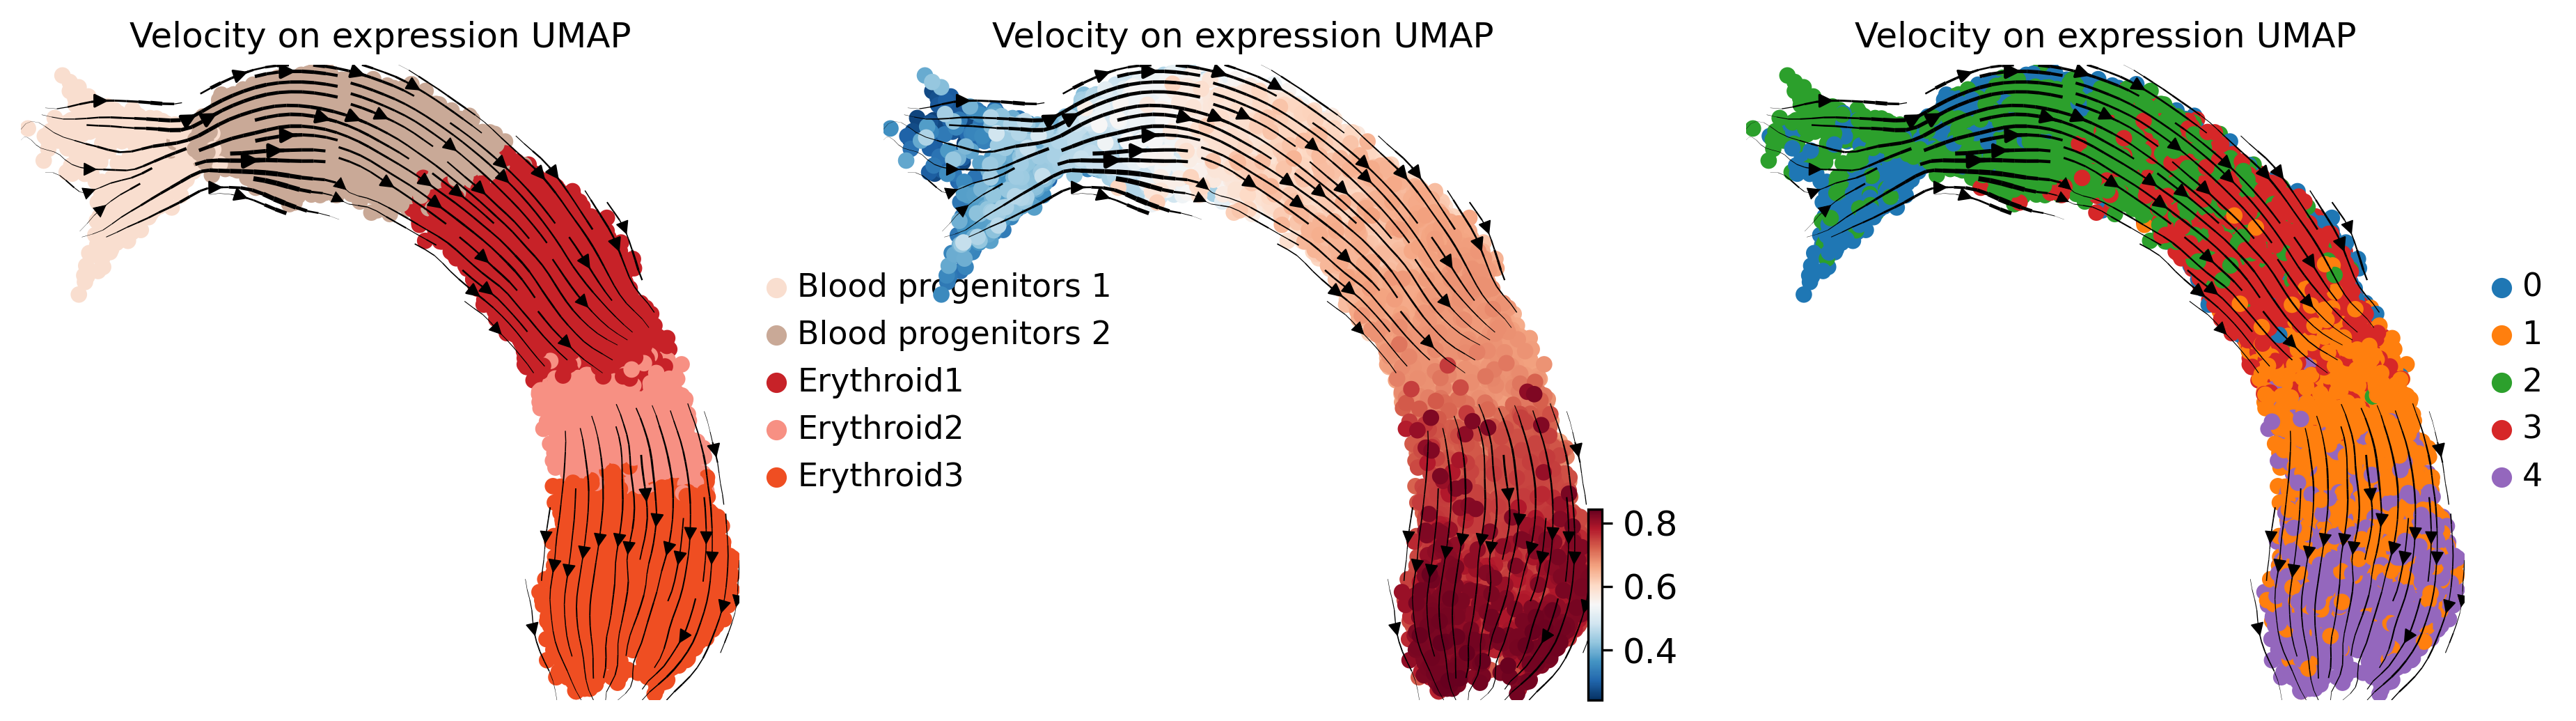

In [16]:
scv.settings.figdir = RESULT_PATH
scv.set_figure_params(style="scvelo", dpi=150, figsize=(5, 4), transparent=True)

color_key = "celltype" if "celltype" in result_adata.obs else "pred_cluster"

scv.pl.velocity_embedding_stream(
    result_adata,
    basis="X_umap_refine_embed_t",
    vkey="pred_vs_norm",
    color=[color_key, "Pred Time", "Expert"],
    legend_loc="right",
    title="Velocity on STEER latent UMAP",
    show=True,
    save="velo_latent_umap.png",
)

scv.pl.velocity_embedding_stream(
    result_adata,
    basis="X_umap",
    vkey="pred_vs_norm",
    color=[color_key, "Pred Time", "Expert"],
    alpha=1,
    legend_loc="right",
    title="Velocity on expression UMAP",
    show=True,
    save="velo_expression_umap.png",
)

result_adata.write(os.path.join(RESULT_PATH, "final_adata_em.h5ad"))